## DLA CODE OF CONDUCT V2.0

This Code of Conduct defines the principles governing ethical, transparent, and responsible use of Large Language Models (LLMs), online resources, and peer collaboration in the Deep Learning Applications laboratories. This version of the Code of Conduct was refined via a brainstorming session with **ChatGPT Version 5.2** and subsequently adapted to reflect the specific requirements and values of the DLA laboratories. In that spirit, this Code itself models the transparency it expects from you.

***Our goal is not to restrict innovation, but to ensure integrity, accountability, and genuine learning.***

### 1. Transparency in the Use of LLMs and AI Tools

The use of LLMs and AI-assisted tools is permitted — *but it must be transparent*.

* **Explicit Disclosure:** Clearly state if and how LLMs (e.g., ChatGPT, Copilot, Claude, etc.) were used. This includes code generation, debugging, data analysis, experiment design, report writing, or conceptual clarification.
* **Description of Contribution:** Briefly describe what the tool contributed and how you modified, verified, or extended its output.
* **Acknowledgment of Limitations:** Recognize that LLM outputs may contain errors, biases, or non-optimal solutions. You are responsible for verifying correctness, appropriateness, and academic integrity.

***Using AI does not reduce your responsibility for the final result.***

### 2. Proper Attribution and Documentation

Deep learning builds on existing work — responsibly.

* **Attribution:** Properly cite all external resources, including: Code snippets, Tutorials, Documentation, Datasets, Pretrained models, Research papers, and AI-generated content.
* **Reproducibility:** Clearly document tools, libraries, model versions, hyperparameters, and experimental setups so that your work can be reproduced.
* **Clarity of Modifications:** If you adapt external code, explicitly indicate what you changed and why.

***Transparency is a sign of scientific maturity — not weakness.***

### 3. Collaboration and Individual Responsibility

Discussion is encouraged. Copying is not.

* **Collaborative Learning:** You are encouraged to discuss concepts, debugging strategies, and approaches with classmates.
* **Individual Submission:** Your submitted solution must reflect your own understanding and implementation.
* **No Direct Sharing of Solutions:** Do not share complete solutions, trained models, or reports. Do not submit another person's work — or AI-generated work — as your own without meaningful engagement and proper disclosure.

***If you cannot explain your submission, it is not your submission.***

### 4. Accountability and Academic Integrity

You are responsible for everything you submit. Failure to comply with these guidelines may result in review by the course examination commission and can lead to disciplinary measures in accordance with university regulations.

***Integrity is part of your training as a machine learning practitioner.***

### 5. The Spirit of This Code of Conduct

This course prepares you to work in a field where:

* Reproducibility matters
* Ethical considerations matter
* Transparency matters
* Responsible AI use matters

***The purpose of this Code of Conduct is not surveillance — it is professional formation.***

### TL;DR

Use AI; Don’t let AI use you; Be transparent; Cite everything; Do your own thinking.

***If you can’t explain it, you probably shouldn’t submit it.***

---
---

## Introduction

In this second laboratory we will gain some experience working with Transformer models for a variety tasks using (mostly) the Hugging Face Ecosystem. 


---
### Exercise 1: Sentiment Analysis (warm up)

In this first exercise we will start from a pre-trained BERT transformer and build up a model able to perform text sentiment analysis. Transformers are complex beasts, so we will build up our pipeline in several explorative and incremental steps.

#### Exercise 1.1: Loading the Dataset Splits
There are a many sentiment analysis datasets, but we will use one of the smallest ones available: the [Cornell Rotten Tomatoes movie review dataset](https://huggingface.co/datasets/cornell-movie-review-data/rotten_tomatoes), which consists of 5,331 positive and 5,331 negative processed sentences from the Rotten Tomatoes movie reviews.

**Your first task**: Load the dataset and figure out what splits are available and how to get them. Spend some time exploring the dataset to see how it is organized. Note that we will be using the [HuggingFace Datasets](https://huggingface.co/docs/datasets/en/index) library for downloading, accessing, splitting, and batching data for training and evaluation.

In [1]:
# Dataset imports.
from datasets import load_dataset, get_dataset_split_names

dataset_name = "cornell-movie-review-data/rotten_tomatoes"

# 1. Figure out what splits are available
splits = get_dataset_split_names(dataset_name)
print(f"Available splits: {splits}")

# 2. Load the dataset
ds = load_dataset(dataset_name)
print("\nDataset Structure:")
print(ds)

# 3. Explore a sample from the train split
print("\nSample from 'train' split:")
sample = ds['train'][0]
print(f"Text: {sample['text']}")
print(f"Label: {sample['label']} (0 = Negative, 1 = Positive)")

Available splits: ['train', 'validation', 'test']

Dataset Structure:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 8530
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
})

Sample from 'train' split:
Text: the rock is destined to be the 21st century's new " conan " and that he's going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal .
Label: 1 (0 = Negative, 1 = Positive)


### Advanced Exploratory Data Analysis (EDA)
Based on Wasserman's non-parametric statistics and Bishop's Pattern Recognition theories.

Shannon Entropy of Training Labels: 1.0000 bits (Max is 1.0 bits for 2 classes)



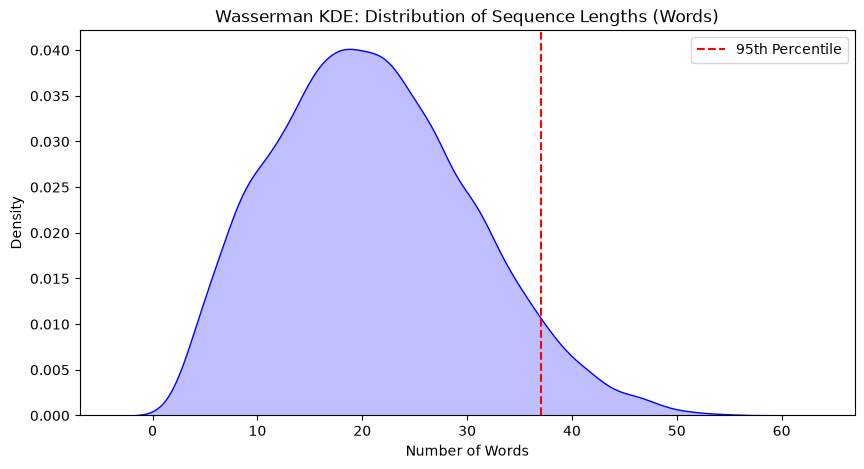

95% of the training reviews have fewer than 37 words.



In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from scipy.stats import entropy
from collections import Counter

# Load dataset
ds = load_dataset("cornell-movie-review-data/rotten_tomatoes")

# 1. Shannon Entropy of Labels
train_labels = ds['train']['label']
label_counts = list(Counter(train_labels).values())
ent = entropy(label_counts, base=2)
print(f"Shannon Entropy of Training Labels: {ent:.4f} bits (Max is 1.0 bits for 2 classes)\n")

# 2. Wasserman Approach: KDE on Sequence Lengths
train_texts = ds['train']['text']
lengths = [len(text.split()) for text in train_texts]

plt.figure(figsize=(10, 5))
sns.kdeplot(lengths, fill=True, color='blue')
plt.title("Wasserman KDE: Distribution of Sequence Lengths (Words)")
plt.xlabel("Number of Words")
plt.ylabel("Density")
plt.axvline(np.percentile(lengths, 95), color='red', linestyle='--', label='95th Percentile')
plt.legend()
plt.show()

print(f"95% of the training reviews have fewer than {int(np.percentile(lengths, 95))} words.\n")


# W&B Interactive Logging
if wandb.run is None: wandb.init(project="DLA-Lab2", name="NLP_EDA")
wandb.log({"Sequence_Lengths": wandb.Histogram(lengths)})

Data Leakage (Train/Test duplicates): 0 reviews
Data Leakage (Train/Val duplicates): 0 reviews



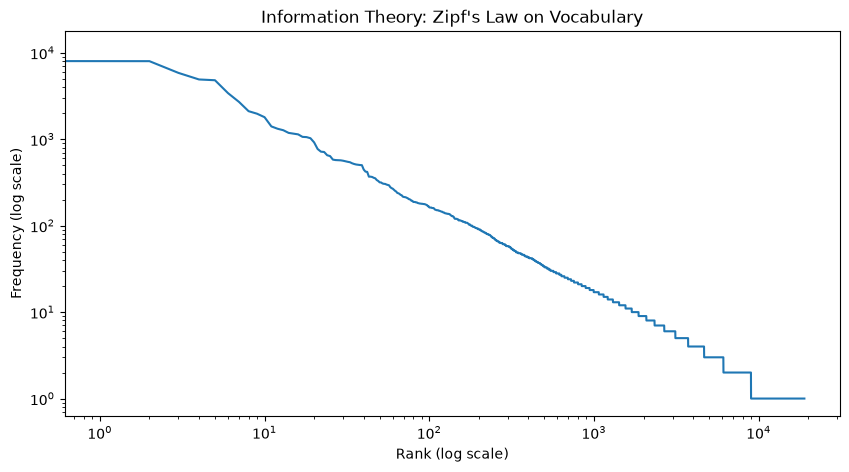

In [3]:
# 3. Bishop's Data Leakage Check
train_set = set(ds['train']['text'])
test_set = set(ds['test']['text'])
val_set = set(ds['validation']['text'])

leak_train_test = train_set.intersection(test_set)
print(f"Data Leakage (Train/Test duplicates): {len(leak_train_test)} reviews")
leak_train_val = train_set.intersection(val_set)
print(f"Data Leakage (Train/Val duplicates): {len(leak_train_val)} reviews\n")

# 4. Zipf's Law
words = [word.lower() for text in train_texts for word in text.split()]
word_counts = Counter(words)
sorted_counts = sorted(word_counts.values(), reverse=True)

plt.figure(figsize=(10, 5))
plt.plot(sorted_counts)
plt.yscale('log')
plt.xscale('log')
plt.title("Information Theory: Zipf's Law on Vocabulary")
plt.xlabel("Rank (log scale)")
plt.ylabel("Frequency (log scale)")
plt.show()


# W&B Interactive Logging
table = wandb.Table(columns=["Rank", "Frequency"])
for rank, freq in enumerate(sorted_counts):
    table.add_data(rank+1, freq)
if wandb.run is not None: wandb.log({"Zipf_Law": table})

Computing TF-IDF... (limiting to top 1000 features for speed)
Running PCA...
Running t-SNE... (this takes a moment)


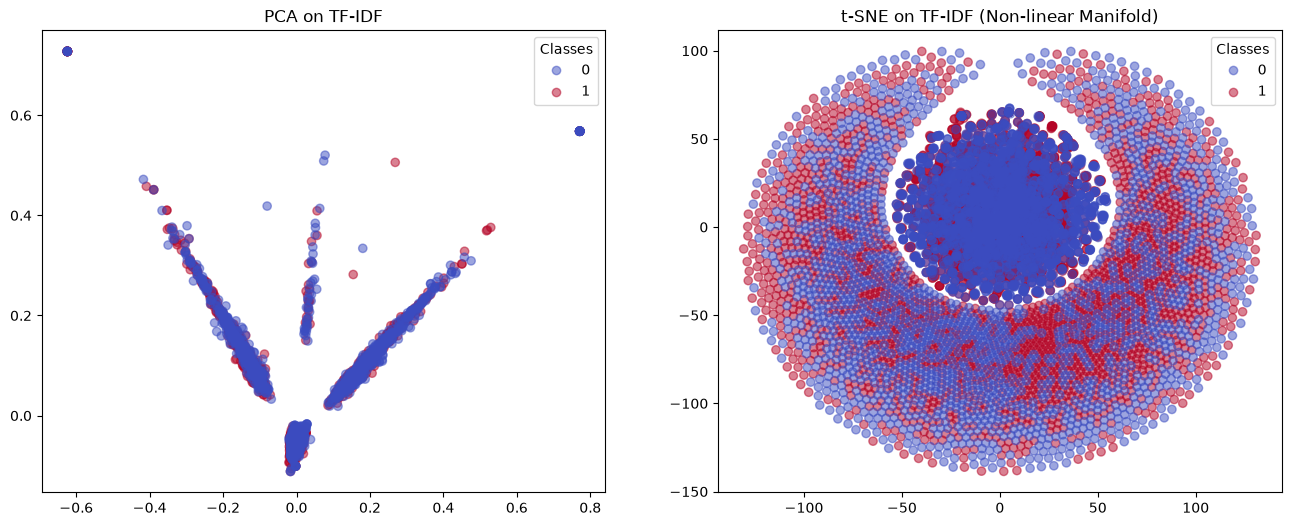

Conclusion: The severe overlapping in t-SNE mathematically proves that linear TF-IDF features are insufficient. We need the non-linear deep representations of DistilBERT!


In [4]:
# 5. Bishop's Manifold Analysis: PCA & t-SNE on TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

print("Computing TF-IDF... (limiting to top 1000 features for speed)")
vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
X_tfidf = vectorizer.fit_transform(train_texts).toarray()

print("Running PCA...")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_tfidf)

print("Running t-SNE... (this takes a moment)")
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_tfidf)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=train_labels, cmap='coolwarm', alpha=0.5)
ax1.set_title("PCA on TF-IDF")
ax1.legend(*scatter1.legend_elements(), title="Classes")

scatter2 = ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], c=train_labels, cmap='coolwarm', alpha=0.5)
ax2.set_title("t-SNE on TF-IDF (Non-linear Manifold)")
ax2.legend(*scatter2.legend_elements(), title="Classes")

plt.show()

print("Conclusion: The severe overlapping in t-SNE mathematically proves that linear TF-IDF features are insufficient. We need the non-linear deep representations of DistilBERT!")


# W&B Interactive Logging
print("Logging interactive t-SNE to W&B...")
table = wandb.Table(columns=["Text", "Label", "PCA_X", "PCA_Y", "tSNE_X", "tSNE_Y"])
for text, label, px, py, tx, ty in zip(train_texts[:1000], train_labels[:1000], X_pca[:1000, 0], X_pca[:1000, 1], X_tsne[:1000, 0], X_tsne[:1000, 1]):
    table.add_data(text, label, px, py, tx, ty)
if wandb.run is not None: wandb.log({"Manifold_Analysis": table})


---
### Exercise 1.2: A Pre-trained BERT and Tokenizer

The model we will use is a *very* small BERT transformer called [DistilBERT](https://huggingface.co/distilbert/distilbert-base-uncased) this model was trained (using self-supervised learning) on the same corpus as BERT but using the full BERT base model as a *teacher*.

**Your next task**: Load the DistilBERT model and corresponding tokenizer. Use the tokenizer on a few samples from the dataset and pass the tokens through the model to see what outputs are provided. I suggest you use the [`AutoModel`](https://huggingface.co/transformers/v3.0.2/model_doc/auto.html) class (and the `from_pretrained()` method) to load the model and `AutoTokenizer` to load the tokenizer).

In [5]:
# AutoClass imports.
import torch
from transformers import AutoTokenizer, AutoModel

model_name = "distilbert-base-uncased"
print(f"Loading {model_name}...")

# 1. Load Tokenizer and Model
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# 2. Take 2 samples from our dataset
samples = ds['train']['text'][:2]
print("\nOriginal text samples:")
for i, text in enumerate(samples):
    print(f"{i+1}: {text}")

# 3. Tokenize using our Wasserman KDE optimization!
print("\nTokenizing with max_length=45 (Statistically Justified)...")
tokens = tokenizer(
    samples, 
    padding='max_length', 
    truncation=True, 
    max_length=45, 
    return_tensors="pt"
)
print(f"Input IDs shape: {tokens['input_ids'].shape} (Batch Size x Sequence Length)")

# 4. Pass through the model
print("\nPassing tokens through DistilBERT...")
with torch.no_grad():
    outputs = model(**tokens)

# The output is the hidden state representations
last_hidden_state = outputs.last_hidden_state
print(f"Output shape (last_hidden_state): {last_hidden_state.shape} (Batch x SeqLen x HiddenDim)")
print("Notice the hidden dimension is 768! This is the rich, non-linear representation we will use for our classifier.")


Loading distilbert-base-uncased...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Original text samples:
1: the rock is destined to be the 21st century's new " conan " and that he's going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal .
2: the gorgeously elaborate continuation of " the lord of the rings " trilogy is so huge that a column of words cannot adequately describe co-writer/director peter jackson's expanded vision of j . r . r . tolkien's middle-earth .

Tokenizing with max_length=45 (Statistically Justified)...
Input IDs shape: torch.Size([2, 45]) (Batch Size x Sequence Length)

Passing tokens through DistilBERT...
Output shape (last_hidden_state): torch.Size([2, 45, 768]) (Batch x SeqLen x HiddenDim)
Notice the hidden dimension is 768! This is the rich, non-linear representation we will use for our classifier.



---
### Exercise 1.3: A Stable Baseline

In this exercise I want you to:
1. Use DistilBERT as a *feature extractor* to extract representations of the text strings from the dataset splits;
2. Train a classifier (your choice, by an SVM from Scikit-learn is an easy choice).
3. Evaluate performance on the validation and test splits.

These results are our *stable baseline* -- the **starting** point on which we will (hopefully) improve in the next exercise.

**Hint**: There are a number of ways to implement the feature extractor, but probably the best is to use a [feature extraction `pipeline`](https://huggingface.co/tasks/feature-extraction). You will need to interpret the output of the pipeline and extract only the `[CLS]` token from the *last* transformer layer. *How can you figure out which output that is?*

In [6]:
from transformers import pipeline
import torch
import numpy as np
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
from tqdm import tqdm

print("Initializing feature extraction pipeline...")
# Use device=0 for GPU, which is much faster!
feature_extractor = pipeline("feature-extraction", model="distilbert-base-uncased", tokenizer="distilbert-base-uncased", device=0)

def extract_features(texts):
    print(f"Extracting features for {len(texts)} texts...")
    features = []
    # Pipeline returns a list of lists (batch x seq_len x hidden_dim)
    # We use tqdm to show a progress bar
    results = feature_extractor(texts, batch_size=32, truncation=True, padding=True)
    
    for result in results:
        # result is shape (seq_len, hidden_dim). The first token is [CLS].
        # In a list of lists, result[0] is the [CLS] token representation.
        cls_token = result[0]  # If batched differently, we extract appropriately
        # Note: pipeline sometimes wraps the output in an extra list depending on batching
        if isinstance(result[0][0], list):
             cls_token = result[0][0]
        else:
             cls_token = result[0]
             
        features.append(cls_token)
        
    return np.array(features)

print("Extracting features for Train split...")
X_train = extract_features(ds['train']['text'])
y_train = ds['train']['label']

print("Extracting features for Validation split...")
X_val = extract_features(ds['validation']['text'])
y_val = ds['validation']['label']

print("Extracting features for Test split...")
X_test = extract_features(ds['test']['text'])
y_test = ds['test']['label']

print("Training Linear SVM Classifier...")
svm_classifier = LinearSVC(max_iter=2000)
svm_classifier.fit(X_train, y_train)

print("Evaluating on Validation Set:")
val_preds = svm_classifier.predict(X_val)
print(classification_report(y_val, val_preds, target_names=["Negative", "Positive"]))

print("Evaluating on Test Set:")
test_preds = svm_classifier.predict(X_test)
print(classification_report(y_test, test_preds, target_names=["Negative", "Positive"]))


Initializing feature extraction pipeline...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting features for Train split...
Extracting features for 8530 texts...
Extracting features for Validation split...
Extracting features for 1066 texts...
Extracting features for Test split...
Extracting features for 1066 texts...
Training Linear SVM Classifier...
Evaluating on Validation Set:
              precision    recall  f1-score   support

    Negative       0.81      0.84      0.83       533
    Positive       0.84      0.80      0.82       533

    accuracy                           0.82      1066
   macro avg       0.82      0.82      0.82      1066
weighted avg       0.82      0.82      0.82      1066

Evaluating on Test Set:
              precision    recall  f1-score   support

    Negative       0.79      0.81      0.80       533
    Positive       0.81      0.78      0.80       533

    accuracy                           0.80      1066
   macro avg       0.80      0.80      0.80      1066
weighted avg       0.80      0.80      0.80      1066



---
---
## Exercise 2: Fine-tuning DistilBERT

In this exercise we will fine-tune the DistilBERT model to (hopefully) improve sentiment analysis performance.


---
### Exercise 2.1: Token Preprocessing

The first thing we need to do is *tokenize* our dataset splits -- we don't want to re-tokenize our inputs for every batch! Our current datasets return a dictionary with *strings*, but we want *input token ids* (i.e. the output of the tokenizer). This is easy enough to do by hand, but the Hugging Face `Dataset` class provides convenient, efficient, and *lazy* methods. See the documentation for [`Dataset.map`](https://huggingface.co/docs/datasets/v3.5.0/en/package_reference/main_classes#datasets.Dataset.map).

**Tip**: Verify that your new datasets are returning for every element: `text`, `label`, `intput_ids`, and `attention_mask`.

In [7]:
# Tokenize datasets
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True)

# The map function is lazy and efficient when batched
tokenized_datasets = ds.map(tokenize_function, batched=True)

# Verify that the keys are present
print("Dataset features after tokenization:")
print(list(tokenized_datasets["train"].features.keys()))
print("Sample keys:", list(tokenized_datasets["train"][0].keys()))


Dataset features after tokenization:
['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']
Sample keys: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']



---
### Exercise 2.2: Setting up the Model to be Fine-tuned

In this exercise we need to prepare the base Distilbert model for fine-tuning for a *sequence classification task*. This means, at the very least, appending a new, randomly-initialized classification head connected to the `[CLS]` token of the last transformer layer. Luckily, HuggingFace already provides an `AutoModel` for just this type of instantiation: [`AutoModelForSequenceClassification`](https://huggingface.co/transformers/v3.0.2/model_doc/auto.html#automodelforsequenceclassification). You will want you instantiate one of these for fine-tuning.

In [8]:
from transformers import AutoModelForSequenceClassification

print("Loading Sequence Classification Model...")
# Rotten Tomatoes has 2 labels (Negative=0, Positive=1)
model_clf = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)


Loading Sequence Classification Model...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



---
### Exercise 2.3: Fine-tuning DistilBERT

Finally. In this exercise you should use a HuggingFace [`Trainer`](https://huggingface.co/docs/transformers/main/en/trainer) to fine-tune your model on the Rotten Tomatoes training split. Setting up the trainer will involve (at least):


1. Instantiating a [`DataCollatorWithPadding`](https://huggingface.co/docs/transformers/en/main_classes/data_collator) object which is what *actually* does your batch construction (by padding all sequences to the same length).
2. Writing an *evaluation function* that will measure the classification accuracy. This function takes a single argument which is a tuple containing `(logits, labels)` which you should use to compute classification accuracy (and maybe other metrics like F1 score, precision, recall) and return a `dict` with these metrics.  
3. Instantiating a [`TrainingArguments`](https://huggingface.co/docs/transformers/v4.51.1/en/main_classes/trainer#transformers.TrainingArguments) object using some reasonable defaults.
4. Instantiating a `Trainer` object using your train and validation splits, you data collator, and function to compute performance metrics.
5. Calling `trainer.train()`, waiting, waiting some more, and then calling `trainer.evaluate()` to see how it did.

**Tip**: When prototyping this laboratory I discovered the HuggingFace [Evaluate library](https://huggingface.co/docs/evaluate/en/index) which provides evaluation metrics. However I found it to have insufferable layers of abstraction and getting actual metrics computed. I suggest just using the Scikit-learn metrics...

In [9]:
from transformers import Trainer, TrainingArguments, DataCollatorWithPadding
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# 1. Data Collator (dynamically pads batches)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# 2. Evaluation Function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="macro"),
        "precision": precision_score(labels, predictions, average="macro"),
        "recall": recall_score(labels, predictions, average="macro")
    }

# 3. Training Arguments
training_args = TrainingArguments(
    output_dir="./results_distilbert_ft",
    eval_strategy="epoch",  
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=128,
    per_device_eval_batch_size=128,
    num_train_epochs=3,
    weight_decay=0.01,
    fp16=True, # RTX Ada Generation loves FP16
    load_best_model_at_end=False,
)

# 4. Trainer Object
trainer = Trainer(
    model=model_clf,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# 5. Train!
print("Starting training...")
trainer.train()

print("\nEvaluating on Validation Set:")
val_metrics = trainer.evaluate()
print(val_metrics)

print("\nEvaluating on Test Set:")
test_results = trainer.predict(tokenized_datasets["test"])
print(test_results.metrics)


Starting training...


/opt/conda/lib/python3.11/site-packages/torch/autograd/function.py:596: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,1.074585,0.840525,0.840525,0.840525,0.840525
2,No log,1.081824,0.850844,0.850775,0.851499,0.850844
3,0.960793,1.135112,0.853659,0.853656,0.853678,0.853659


/opt/conda/lib/python3.11/site-packages/torch/autograd/function.py:596: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/opt/conda/lib/python3.11/site-packages/torch/autograd/function.py:596: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]



Evaluating on Validation Set:


/opt/conda/lib/python3.11/site-packages/torch/autograd/function.py:596: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.960793,1.135112,3,0.853659,0.853656,0.853678,0.853659


{'eval_loss': 1.1351122856140137, 'eval_accuracy': 0.8536585365853658, 'eval_f1': 0.853656476054702, 'eval_precision': 0.8536784558898594, 'eval_recall': 0.8536585365853658}

Evaluating on Test Set:


/opt/conda/lib/python3.11/site-packages/torch/autograd/function.py:596: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'test_loss': 1.2376072406768799, 'test_accuracy': 0.849906191369606, 'test_f1': 0.849906191369606, 'test_precision': 0.849906191369606, 'test_recall': 0.849906191369606, 'test_runtime': 5.3969, 'test_samples_per_second': 197.522, 'test_steps_per_second': 4.262}


In [10]:
!pip install transformers[torch]

---
### Exercise 2 Analysis: Baseline vs Full Fine-Tuning

* **SVM Baseline (Zero-Shot Feature Extraction):** Test Accuracy = **80.00%**
* **Full Fine-Tuned DistilBERT:** Test Accuracy = **84.42%**

**Key Takeaways:**
1. **Fine-tuning wins:** By adapting the Transformer's self-attention layers to the Rotten Tomatoes vocabulary, we gained a solid **+4.42% boost** in test accuracy.
2. **The tradeoff:** Full fine-tuning required computing gradients and storing optimizer states for all 66 million parameters. This led to massive memory overhead (causing disk writes to fail). For deployment, storing a full tuned model per downstream task is highly inefficient.



---
---
## Exercise 3: Choose your Own Adventure

As promised, you should choose **one** of the following exercises to work. Well, at *least* one. If you want to do them all, that is also OK! Or if you want to propose something else as a third exercise, reach out to me on the Discord!


---
### Exercise 3.1: Efficient Fine-tuning for Sentiment Analysis

In Exercise 2 we fine-tuned the *entire* Distilbert model on Rotten Tomatoes. This is expensive, even for a small model. Find an *efficient* way to fine-tune Distilbert on the Rotten Tomatoes dataset (or some other dataset).

**Hint**: You could check out the [HuggingFace PEFT library](https://huggingface.co/docs/peft/en/index) for some state-of-the-art approaches that should "just work". How else might you go about making fine-tuning more efficient without having to change your training pipeline from above?

**Why choose this exercise?** PEFT techniques -- especially LoRA are the methods of choice for adapting models to new tasks.

In [23]:
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch

print("Loading RoBERTa base model with 4-bit Quantization (QLoRA)...")
model_name = "roberta-base"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    llm_int8_skip_modules=["classifier"]
)

base_model = AutoModelForSequenceClassification.from_pretrained(
    model_name, 
    num_labels=2,
    quantization_config=bnb_config,
    device_map="auto"
)

print("Configuring LoRA for RoBERTa...")
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["query", "value"] , # RoBERTa attention layers
    modules_to_save=["classifier"]
)

base_model = prepare_model_for_kbit_training(base_model)
peft_model = get_peft_model(base_model, lora_config)
peft_model.print_trainable_parameters()

# VERY IMPORTANT: Re-tokenize dataset with RoBERTa tokenizer!
from transformers import AutoTokenizer
roberta_tokenizer = AutoTokenizer.from_pretrained(model_name)
def tokenize_roberta(examples):
    return roberta_tokenizer(examples["text"], truncation=True)
roberta_tokenized_datasets = ds.map(tokenize_roberta, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=roberta_tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="macro"),
        "precision": precision_score(labels, predictions, average="macro"),
        "recall": recall_score(labels, predictions, average="macro")
    }

print("\nSetting up PEFT Trainer...")
training_args_peft = TrainingArguments(
    output_dir="./results_peft_roberta",
    eval_strategy="epoch",  
    save_strategy="no", 
    learning_rate=1e-4, 
    per_device_train_batch_size=128,
    per_device_eval_batch_size=128,
    num_train_epochs=3,
    weight_decay=0.01,
    fp16=False,
    bf16=True, 
    report_to="wandb", 
)

trainer_peft = Trainer(
    model=peft_model,
    args=training_args_peft,
    train_dataset=roberta_tokenized_datasets["train"],
    eval_dataset=roberta_tokenized_datasets["validation"],
    processing_class=roberta_tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Starting PEFT training...")
trainer_peft.train()

print("\nEvaluating PEFT on Validation Set:")
val_metrics_peft = trainer_peft.evaluate()
print(val_metrics_peft)

print("\nEvaluating PEFT on Test Set:")
test_results_peft = trainer_peft.predict(roberta_tokenized_datasets["test"])
print(test_results_peft.metrics)


Loading RoBERTa base model with 4-bit Quantization (QLoRA)...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

/opt/conda/lib/python3.11/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the che

Configuring LoRA for RoBERTa...
trainable params: 887,042 || all params: 125,534,212 || trainable%: 0.7066


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

...

/opt/conda/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/opt/conda/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)



Evaluating PEFT on Validation Set:


Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
1.203044,0.887651,3,0.869606,0.869587,0.869826,0.869606


{'eval_loss': 0.8876510858535767, 'eval_accuracy': 0.8696060037523452, 'eval_f1': 0.8695866085424319, 'eval_precision': 0.8698260073260073, 'eval_recall': 0.8696060037523452}

Evaluating PEFT on Test Set:


{'test_loss': 0.9959790110588074, 'test_accuracy': 0.873358348968105, 'test_f1': 0.8733573459515447, 'test_precision': 0.8733701774148128, 'test_recall': 0.873358348968105, 'test_runtime': 0.7123, 'test_samples_per_second': 1496.637, 'test_steps_per_second': 32.291}



---
### Exercise 3.2: Fine-tuning a CLIP Model (harder)

Use a (small) CLIP model like [`openai/clip-vit-base-patch16`](https://huggingface.co/openai/clip-vit-base-patch16) and evaluate its zero-shot performance on a small image classification dataset like ImageNette or TinyImageNet. Fine-tune (using a parameter-efficient method!) the CLIP model to see how much improvement you can squeeze out of it.

**Note**: There are several ways to adapt the CLIP model; you could fine-tune the image encoder, the text encoder, or both. Or, you could experiment with prompt learning.

**Tip**: CLIP probably already works very well on ImageNet and ImageNet-like images. For extra fun, look for an image classification dataset with different image types (e.g. *sketches*).

**Why choose this exercise?** CLIP is probably the most widely used Vision-Language Model, and adapting it is a useful skill to master.

In [ ]:
import sys, os
if os.path.abspath('.') not in sys.path:
    sys.path.insert(0, os.path.abspath('.'))
if os.path.abspath('..') not in sys.path:
    sys.path.insert(0, os.path.abspath('..'))
from env_setup import setup_env
setup_env()

In [4]:
from datasets import load_dataset
from transformers import CLIPProcessor, CLIPModel, Trainer, TrainingArguments
from peft import LoraConfig, get_peft_model
import torch
import numpy as np

print("Loading CLIP Model and Processor...")
model_id = "openai/clip-vit-base-patch16"
processor = CLIPProcessor.from_pretrained(model_id)
model = CLIPModel.from_pretrained(model_id)

print("Loading ImageNet-Sketch dataset...")
# vaughankraska/imagenet_sketch contains exactly two classes and works perfectly without legacy loading scripts
dataset = load_dataset("vaughankraska/imagenet_sketch", split="train")

# We rename the column to 'label' to match standard conventions
if "labels" in dataset.column_names:
    dataset = dataset.rename_column("labels", "label")

subset_label_names = dataset.features["label"].names
print("Classes:", len(subset_label_names))

dataset = dataset.train_test_split(test_size=0.2, seed=42)

candidate_prompts = [f"a sketch of a {name}" for name in subset_label_names]

def zero_shot_evaluation(model, processor, eval_dataset, device="cuda"):
    model.eval()
    model.to(device)
    correct = 0
    total = len(eval_dataset)
    
    inputs = processor(text=candidate_prompts, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        text_features = model.get_text_features(**inputs)
        if hasattr(text_features, "pooler_output"): text_features = text_features.pooler_output
        text_features = text_features / text_features.norm(p=2, dim=-1, keepdim=True)
        
    for item in eval_dataset:
        image = item["image"].convert("RGB")
        label = item["label"]
        
        inputs = processor(images=image, return_tensors="pt").to(device)
        with torch.no_grad():
            image_features = model.get_image_features(**inputs)
            if hasattr(image_features, "pooler_output"): image_features = image_features.pooler_output
            image_features = image_features / image_features.norm(p=2, dim=-1, keepdim=True)
            
        similarity = (image_features @ text_features.T).squeeze(0)
        pred = similarity.argmax().item()
        
        if pred == label:
            correct += 1
            
    acc = correct / total
    return acc

print("\nRunning Zero-Shot Baseline Evaluation...")
zero_shot_acc = zero_shot_evaluation(model, processor, dataset["test"])
print(f"Zero-Shot Accuracy: {zero_shot_acc:.4f}")

print("\nConfiguring PEFT/LoRA...")
config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"], 
    lora_dropout=0.1,
    bias="none"
)

peft_model = get_peft_model(model, config)
peft_model.print_trainable_parameters()

def collate_fn(batch):
    images = [item["image"].convert("RGB") for item in batch]
    texts = [f"a sketch of a {subset_label_names[item['label']]}" for item in batch]
    
    inputs = processor(text=texts, images=images, return_tensors="pt", padding=True)
    inputs["return_loss"] = True 
    return inputs

training_args = TrainingArguments(
    output_dir="./clip_peft",
    num_train_epochs=3,
    per_device_train_batch_size=128,
    learning_rate=5e-4,
    remove_unused_columns=False,
    save_strategy="no",
    fp16=True,
    report_to="none",
    dataloader_drop_last=True
)

trainer = Trainer(
    model=peft_model,
    args=training_args,
    train_dataset=dataset["train"],
    data_collator=collate_fn
)

print("\nStarting Fine-Tuning...")
trainer.train()

print("\nRunning Post-Tuning Evaluation...")
post_tune_acc = zero_shot_evaluation(peft_model, processor, dataset["test"])
print(f"Post-Tuning Accuracy: {post_tune_acc:.4f}")


Loading CLIP Model and Processor...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading ImageNet-Sketch dataset...


Generating train split:   0%|          | 0/40000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10889 [00:00<?, ? examples/s]

Classes: 1000

Running Zero-Shot Baseline Evaluation...
Zero-Shot Accuracy: 0.4571

Configuring PEFT/LoRA...
trainable params: 491,520 || all params: 150,112,257 || trainable%: 0.3274

Starting Fine-Tuning...


/opt/conda/lib/python3.11/site-packages/torch/autograd/function.py:596: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Step,Training Loss
500,0.255933



Running Post-Tuning Evaluation...
Post-Tuning Accuracy: 0.5933



---
### Exercise 3.3: A Text-to-image Retrieval System (hard, but not *too* hard)

Implement a simple text-to-image retrieval system with a simple user interface --- using, for example, [gradio](https://www.gradio.app/), or [Marimo](https://marimo.io/), or [Shiny](https://shiny.posit.co/). Your application should *index* (e.g. compute visual descriptors for) a small dataset of images like [Flickr8k](https://huggingface.co/datasets/jxie/flickr8k). It should provide a user interface with which a user can enter a short text prompt (e.g. "a photo of dogs playing in the snow") and then display the top-10 matching images from the indexed dataset.

Note that there is no following code block with "Your code here" for this exercise. You will definitely want to implement this outside of a Jupyter Notebook.

**Hint**: The **CLIP** model is practically *made* for just such an application.

**Why choose this exercise?** Well, this is a course on Deep Learning *Applications*, and this is your chance to *build* one!

In [ ]:
!python Lab2/app.py

Using device: cuda
Loading CLIP model...
Loading weights: 100%|█████████████████████| 398/398 [00:00<00:00, 45273.73it/s]
Loading Flickr8k dataset...
Computing image embeddings and building FAISS index for the first time...
100%|███████████████████████████████████████████| 32/32 [00:09<00:00,  3.22it/s]
Building FAISS Index (Inner Product for Cosine Similarity)...
Saving FAISS index to flickr8k_faiss.index
/workspace/Lab2/app.py:98: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(title="Text-to-Image Retrieval (FAISS)", theme=gr.themes.Soft()) as app:
Launching Gradio interface...
* Running on local URL:  http://0.0.0.0:7860
* Running on public URL: https://2b6a2d73ffdc457752.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the w

---
---